<a href="https://colab.research.google.com/github/andreydesousa92-byte/ML_Intermittent_Sales/blob/main/model_trainning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intermittent Sales Classification

## Business Case

In B2B sales environments, customer demand is often irregular, some customers place orders every month, others disappear for quarters at a time. This inconsistency makes it difficult for sales teams to know who to contact proactively, often leading to missed opportunities or wasted outreach effort.

## Purpose

This project builds a binary classification model that predicts whether a customer will place a purchase order in the following month. The output is a ranked contact list with probability scores, giving the sales team a data-driven prioritization tool rather than relying on intuition or blanket outreach campaigns.

## What This Notebook Does

Starting from raw transactional sales data, the notebook engineers customer-level behavioral features, trains and compares four machine learning models .: Logistic Regression, Random Forest, XGBoost, and Deep Learning and selects the best performer based on Precision-Recall analysis aligned with the business context. The final model is exported to Google Drive for use in the scoring notebook, where it can be applied to new data to generate monthly contact lists.

## Template Notice

This project is designed as a reusable template. The Northwind dataset is used here for demonstration purposes. To adapt it to your own data, replace the raw data sources and ensure your input follows the required feature schema described in the README.


# Importing databases

In [1]:
import pandas as pd
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    classification_report,
    roc_auc_score
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

In [2]:
# CATEGORIES
url = "https://raw.githubusercontent.com/andreydesousa92-byte/ML_Intermittent_Sales/main/data/raw/categories.csv"
df_categories = pd.read_csv(url)
df_categories.head()

,categoryID,categoryName,description
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales"
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an..."
2,3,Confections,"Desserts, candies, and sweet breads"
3,4,Dairy Products,Cheeses
4,5,Grains & Cereals,"Breads, crackers, pasta, and cereal"


In [3]:
# CUSTOMERS
url = "https://raw.githubusercontent.com/andreydesousa92-byte/ML_Intermittent_Sales/main/data/raw/customers.csv"
df_customers = pd.read_csv(url, encoding='latin1')
df_customers.head()

,customerID,companyName,contactName,contactTitle,city,country
0,ALFKI,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany
1,ANATR,Ana Trujillo Emparedados y helados,Ana Trujillo,Owner,Mexico City,Mexico
2,ANTON,Antonio Moreno Taquería,Antonio Moreno,Owner,Mexico City,Mexico
3,AROUT,Around the Horn,Thomas Hardy,Sales Representative,London,UK
4,BERGS,Berglunds snabbköp,Christina Berglund,Order Administrator,Luleå,Sweden


In [4]:
# ORDERDETAILS
url = "https://raw.githubusercontent.com/andreydesousa92-byte/ML_Intermittent_Sales/main/data/raw/order_details.csv"
df_salesorders = pd.read_csv(url, encoding='latin1')
df_salesorders.head()

,orderID,productID,unitPrice,quantity,discount
0,10248,11,14.0,12,0.0
1,10248,42,9.8,10,0.0
2,10248,72,34.8,5,0.0
3,10249,14,18.6,9,0.0
4,10249,51,42.4,40,0.0


In [5]:
# ORDERDES
url = "https://raw.githubusercontent.com/andreydesousa92-byte/ML_Intermittent_Sales/main/data/raw/orders.csv"
df_orders = pd.read_csv(url)
df_orders.head()


,orderID,customerID,employeeID,orderDate,requiredDate,shippedDate,shipperID,freight
0,10248,VINET,5,2013-07-04,2013-08-01,2013-07-16,3,32.38
1,10249,TOMSP,6,2013-07-05,2013-08-16,2013-07-10,1,11.61
2,10250,HANAR,4,2013-07-08,2013-08-05,2013-07-12,2,65.83
3,10251,VICTE,3,2013-07-08,2013-08-05,2013-07-15,1,41.34
4,10252,SUPRD,4,2013-07-09,2013-08-06,2013-07-11,2,51.30


In [6]:
# ORDERDETAILS
url = "https://raw.githubusercontent.com/andreydesousa92-byte/ML_Intermittent_Sales/main/data/raw/products.csv"
df_products = pd.read_csv(url, encoding='latin1')
df_products.head()

,productID,productName,quantityPerUnit,unitPrice,discontinued,categoryID
0,1,Chai,10 boxes x 20 bags,18.00,0,1
1,2,Chang,24 - 12 oz bottles,19.00,0,1
2,3,Aniseed Syrup,12 - 550 ml bottles,10.00,0,2
3,4,Chef Anton's Cajun Seasoning,48 - 6 oz jars,22.00,0,2
4,5,Chef Anton's Gumbo Mix,36 boxes,21.35,1,2


In [7]:
# Min and Max dates
min_date = df_orders['orderDate'].min()
max_date = df_orders['orderDate'].max()

print("Min order date:", min_date)
print("Max order date:", max_date)

Min order date: 2013-07-04
Max order date: 2015-05-06


In [8]:
# Create date range
calendar_df = pd.DataFrame({'Date': pd.date_range(start=min_date, end=max_date)})

# Extract year and month as separate columns
calendar_df['Year'] = calendar_df['Date'].dt.year
calendar_df['Month'] = calendar_df['Date'].dt.month
calendar_df['Day'] = calendar_df['Date'].dt.day

calendar_df.head(10)

,Date,Year,Month,Day
0,2013-07-04,2013,7,4
1,2013-07-05,2013,7,5
2,2013-07-06,2013,7,6
3,2013-07-07,2013,7,7
4,2013-07-08,2013,7,8
5,2013-07-09,2013,7,9
6,2013-07-10,2013,7,10
7,2013-07-11,2013,7,11
8,2013-07-12,2013,7,12
9,2013-07-13,2013,7,13


# Transform
The first step is to connect the databases.
Using the sales orders database as the core source, and transform the data into features that will be useful for our model.
We are using sales orders instead of billed sales because orders better reflect the actual demand requested by customers.

In [9]:
!pip install duckdb
import duckdb

result_df  = duckdb.query("""
WITH
first_order AS (
    SELECT
        customerID,
        DATE_TRUNC('month', CAST(MIN(orderDate) AS DATE)) AS first_order_month
    FROM df_orders
    GROUP BY customerID
),
calendar AS(
    SELECT
        MIN(Date) AS Date,
        Year AS sales_year,
        Month AS sales_month
    FROM calendar_df
    group by
        Year,
        Month
),
customer_months AS (
    SELECT
        f.customerID as keyId,
        c.Date,
        c.sales_year,
        c.sales_month
    FROM first_order f
    JOIN calendar c
        ON c.Date >= f.first_order_month
),
sales AS (
    SELECT
        YEAR(CAST(o.orderDate AS DATE)) AS sales_year,
        MONTH(CAST(o.orderDate AS DATE)) AS sales_month,
        o.customerID AS keyId,
        SUM(so.quantity) AS Sales_EA,
        COUNT(*) AS Num_Sales_Orders,
        CASE WHEN SUM(so.discount) > 0 THEN 1 ELSE 0 END AS Has_Discount
    FROM df_orders o
    LEFT JOIN df_salesorders so
      ON o.OrderID = so.OrderID
    GROUP BY
        YEAR(CAST(o.orderDate AS DATE)) ,
        MONTH(CAST(o.orderDate AS DATE)),
        o.customerID
)
SELECT
    g.Date,
    g.sales_year,
    g.sales_month,
    g.keyId,
    COALESCE(s.Has_Discount, 0) AS Discount,
    COALESCE(s.Sales_EA, 0) AS Sales_EA,

    -- CAPTURES NEXT MONTH SALES
    LEAD(COALESCE(s.Sales_EA, 0)) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
    ) AS Next_Month_Sales_EA,

    -- BINARY TO INDICATE IF NEXT MONTH THERE WILL BE SALES OR NOT
    CASE
        WHEN
        LEAD(COALESCE(s.Sales_EA, 0)) OVER (
            PARTITION BY g.keyId
            ORDER BY g.sales_year, g.sales_month
        ) > 0
        THEN 1
        ELSE 0
    END AS Have_Sales_NMonth,

    -- SIN AND COS ARE RELEVANT FOR SEASONALITY
    SIN(2 * PI() * g.sales_month / 12) AS month_sin,
    COS(2 * PI() * g.sales_month / 12) AS month_cos,

    -- SALES LAGS
    LAG(COALESCE(s.Sales_EA, 0), 1) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
    ) AS Sales_Lag_1,
    LAG(COALESCE(s.Sales_EA, 0), 2) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
    ) AS Sales_Lag_2,
    LAG(COALESCE(s.Sales_EA, 0), 3) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
    ) AS Sales_Lag_3,

    -- SALES ORDERS COUNT LAG
    LAG(COALESCE(s.Num_Sales_Orders, 0), 1) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
    ) AS Sales_Orders_Lag_1,
    LAG(COALESCE(s.Num_Sales_Orders, 0), 2) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
    ) AS Sales_Orders_Lag_2,
    LAG(COALESCE(s.Num_Sales_Orders, 0), 3) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
    ) AS Sales_Orders_Lag_3,

    -- ROLLING SUMS
    SUM(COALESCE(s.Num_Sales_Orders, 0)) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS SO_Last_3_Months,

    -- MONTHS SINCE LAST SALES
    CASE
        WHEN MAX(CASE WHEN COALESCE(s.Sales_EA, 0) > 0 THEN (g.sales_year * 12 + g.sales_month) END)
             OVER (PARTITION BY g.keyId ORDER BY g.sales_year, g.sales_month
                   ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) IS NULL
        THEN 999
        ELSE (g.sales_year * 12 + g.sales_month) -
             MAX(CASE WHEN COALESCE(s.Sales_EA, 0) > 0 THEN (g.sales_year * 12 + g.sales_month) END)
                 OVER (PARTITION BY g.keyId ORDER BY g.sales_year, g.sales_month
                       ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
    END AS months_since_last_sale,

    -- L2M WITHOUT SALES RULE
    CASE
        WHEN
            LAG(COALESCE(s.Sales_EA, 0), 1) OVER (
                PARTITION BY g.keyId
                ORDER BY g.sales_year, g.sales_month
            ) = 0 AND
            LAG(COALESCE(s.Sales_EA, 0), 2) OVER (
                PARTITION BY g.keyId
                ORDER BY g.sales_year, g.sales_month
            ) =0
        THEN 1
        ELSE 0
    END AS no_sales_L2M,

    -- SALES TREND
    COALESCE(LAG(s.Num_Sales_Orders,1) OVER (PARTITION BY g.keyId ORDER BY g.sales_year, g.sales_month),0) -
    COALESCE(LAG(s.Num_Sales_Orders,2) OVER (PARTITION BY g.keyId ORDER BY g.sales_year, g.sales_month),0)
    AS Lag_Trend_1_2,

    COALESCE(LAG(s.Num_Sales_Orders,2) OVER (PARTITION BY g.keyId ORDER BY g.sales_year, g.sales_month),0) -
    COALESCE(LAG(s.Num_Sales_Orders,3) OVER (PARTITION BY g.keyId ORDER BY g.sales_year, g.sales_month),0)
    AS Lag_Trend_2_3,

    SUM(CASE WHEN COALESCE(s.Sales_EA,0) > 0 THEN 1 ELSE 0 END)
    OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    )
    / NULLIF(
        COUNT(*) OVER (
            PARTITION BY g.keyId
            ORDER BY g.sales_year, g.sales_month
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ), 0
    )
    AS Activity_Ratio,

    -- STANDARD DEVIATION OF LAST 6 MONTHS
    STDDEV(COALESCE(s.Num_Sales_Orders,0)) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
        ROWS BETWEEN 5 PRECEDING AND CURRENT ROW
    ) AS Sales_Std_6M,

    -- 6M ACITIVY RATE
    SUM(
        CASE WHEN COALESCE(s.Num_Sales_Orders,0) > 0 THEN 1 ELSE 0 END
    ) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
        ROWS BETWEEN 5 PRECEDING AND CURRENT ROW
    ) / 6.0 AS Activity_Rate_6M,

    -- 3M ACITIVY RATE
    SUM(
        CASE WHEN COALESCE(s.Num_Sales_Orders,0) > 0 THEN 1 ELSE 0 END
    ) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) / 3.0 AS Activity_Rate_3M,

    -- RECENCY INTERACTION
    Activity_Ratio * months_since_last_sale AS Activity_Recency_Interaction,

    -- SEASONALITY INTERACTION
    month_sin * Activity_Ratio AS Season_Activity_Interaction,

    -- NUMBER OF SALES ORDERS
    SUM(COALESCE(s.Num_Sales_Orders,0)) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
        ROWS BETWEEN 5 PRECEDING AND CURRENT ROW
    ) AS Num_SalesOrders_L6M,

    -- NUMBER OF SALES ORDERS
    SUM(COALESCE(s.Num_Sales_Orders,0)) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS Num_SalesOrders_L3M,

    -- NUMBER OF SALES ORDERS
    SUM(COALESCE(s.Num_Sales_Orders,0)) OVER (
        PARTITION BY g.keyId
        ORDER BY g.sales_year, g.sales_month
        ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ) AS Num_SalesOrders_L2M

FROM (
    SELECT
        Date,
        sales_year,
        sales_month,
        keyId
    FROM customer_months
) g
LEFT JOIN sales s
    ON g.sales_year = s.sales_year
   AND g.sales_month = s.sales_month
   AND g.keyId = s.keyId
ORDER BY
    g.keyId,
    g.sales_year,
    g.sales_month;
""").to_df()

In [10]:
result_df.head()

,Date,sales_year,sales_month,keyId,Discount,Sales_EA,Next_Month_Sales_EA,Have_Sales_NMonth,month_sin,month_cos,...,Lag_Trend_2_3,Activity_Ratio,Sales_Std_6M,Activity_Rate_6M,Activity_Rate_3M,Activity_Recency_Interaction,Season_Activity_Interaction,Num_SalesOrders_L6M,Num_SalesOrders_L3M,Num_SalesOrders_L2M
0,2014-08-01,2014,8,ALFKI,1,38.0,0.0,0,-8.660254e-01,-5.000000e-01,...,0,1.000000,NaN,0.166667,0.333333,0.0,-8.660254e-01,3.0,3.0,3.0
1,2014-09-01,2014,9,ALFKI,0,0.0,41.0,1,-1.000000e+00,-1.836970e-16,...,0,0.500000,2.121320,0.166667,0.333333,0.5,-5.000000e-01,3.0,3.0,3.0
2,2014-10-01,2014,10,ALFKI,0,41.0,0.0,0,-8.660254e-01,5.000000e-01,...,3,0.666667,1.732051,0.333333,0.666667,0.0,-5.773503e-01,6.0,6.0,3.0
3,2014-11-01,2014,11,ALFKI,0,0.0,0.0,0,-5.000000e-01,8.660254e-01,...,-3,0.500000,1.732051,0.333333,0.333333,0.5,-2.500000e-01,6.0,3.0,3.0
4,2014-12-01,2014,12,ALFKI,0,0.0,17.0,1,-2.449294e-16,1.000000e+00,...,3,0.400000,1.643168,0.333333,0.333333,0.8,-9.797174e-17,6.0,3.0,0.0


# Nominating Features

Feature selection is one of the most critical steps in any machine learning project.
In our case, after several experiments and given the limited number of training samples, we will keep the features simple and avoid introducing noise by including multiple variations of the same measurements.

In [11]:
feature_cols = [
    "Discount",
    # "month_sin",
    # "month_cos",
    "Sales_Orders_Lag_1",
    "Sales_Orders_Lag_2",
    "Sales_Orders_Lag_3",
    "months_since_last_sale",
    # "no_sales_L2M",
    # "Sales_Std_6M",
    # "Lag_Trend_1_2",
    # "Lag_Trend_2_3",
    "Activity_Ratio",
    # "Activity_Rate_6M",
    "Activity_Rate_3M",
    "Activity_Recency_Interaction",
    "Season_Activity_Interaction",
    # "Num_SalesOrders_L6M",
    "Num_SalesOrders_L3M",
    # "Num_SalesOrders_L2M"
]

In [12]:
label_col = ["Have_Sales_NMonth"]

# Analytics

We will calculate the percentage of cases with intermittent sales, defined as instances where a material does not sell in the following month.

In [13]:
num_ones = (result_df['Have_Sales_NMonth'] == 1).sum()
total_rows = len(result_df)
percentage = (num_ones / total_rows) * 100

print(f"Percentage of rows with Have_Sales_NMonth = 1: {percentage:.2f}%")

Percentage of rows with Have_Sales_NMonth = 1: 32.04%


A histogram will help us visualize the distribution of the ratio.

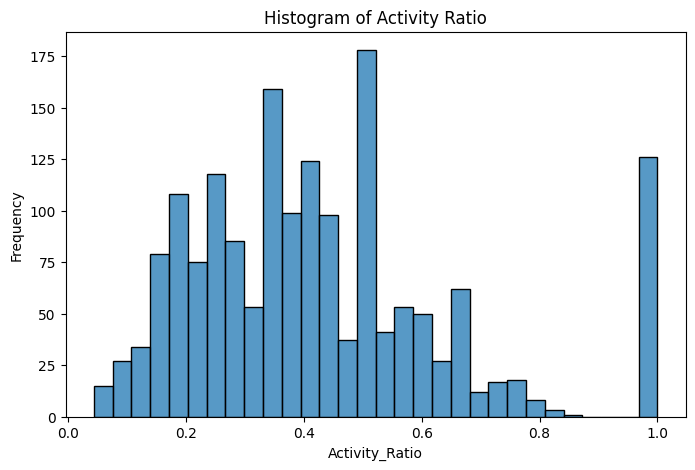

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(result_df["Activity_Ratio"], bins=30)

plt.title("Histogram of Activity Ratio")
plt.xlabel("Activity_Ratio")
plt.ylabel("Frequency")
plt.show()

Group those cases will help to better indentify the chellange

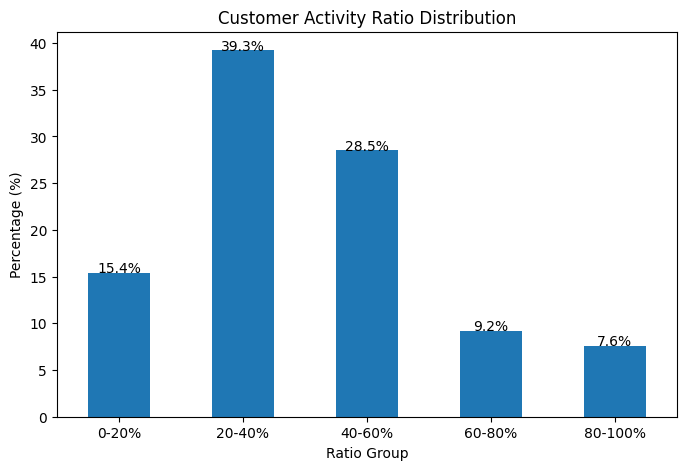

In [15]:
# If ratio is between 0 and 1, keep bins like this:
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]

# Create grouped variable
result_df["Activity_Group"] = pd.cut(
    result_df["Activity_Ratio"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate percentage distribution
group_percent = (
    result_df["Activity_Group"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

# Plot
plt.figure(figsize=(8,5))
ax = group_percent.plot(kind="bar")

# Add percentage labels on bars
for i, v in enumerate(group_percent):
    ax.text(i, v, f"{v:.1f}%", ha="center")

plt.title("Customer Activity Ratio Distribution")
plt.xlabel("Ratio Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.show()

## Correlation Matrix

The correlation matrix is a useful tool for identifying linear relationships between features. Although it does not necessarily indicate whether features are correlated in a way that affects models like deep learning, it provides valuable context and helps highlight simple, interpretable connections.

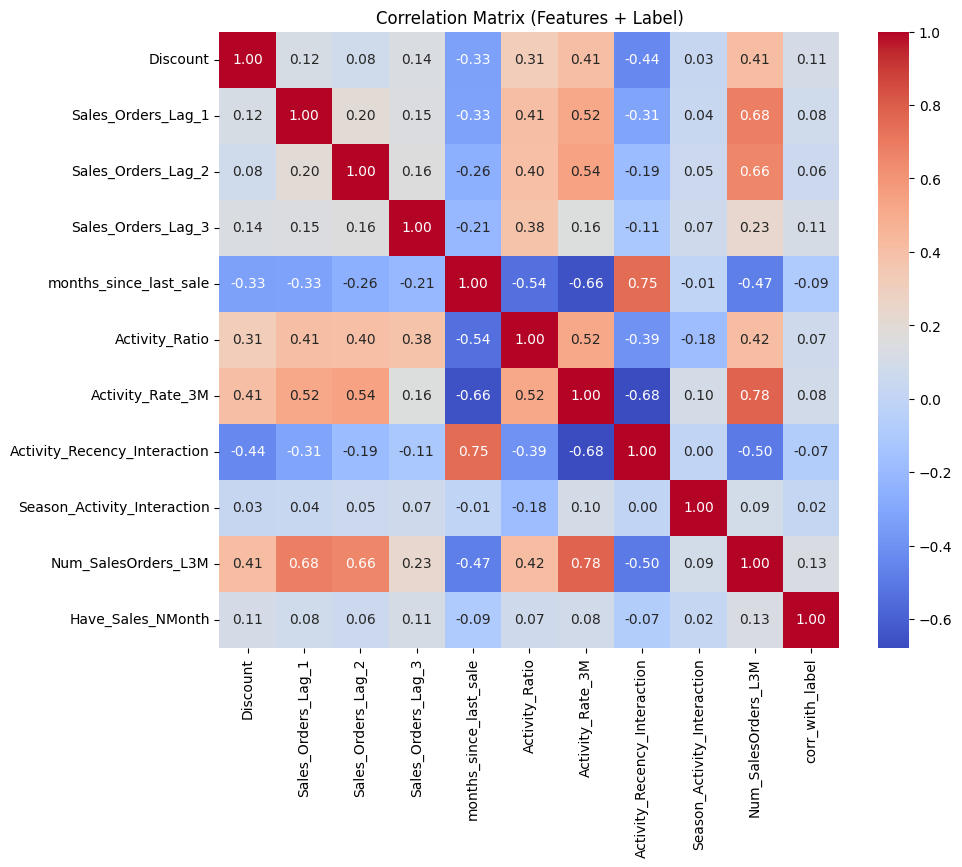

In [16]:
# Feature-feature correlations
cor_matrix = result_df[feature_cols].corr(method='pearson')

# Correlation with label
label_name = label_col[0]
label_corrs = result_df[feature_cols].apply(lambda x: x.corr(result_df[label_name]))

# Add as a column
cor_matrix["corr_with_label"] = label_corrs

# Add label row
label_row = label_corrs.tolist() + [1.0]
cor_matrix.loc[label_name] = label_row

plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Features + Label)")
plt.show()

# Splitting Training and Validation & Scaling features

Since this is a time series problem, we will split the data based on dates, keeping the most recent rows for validation to prevent data leakage.

In [17]:
# Split train and val
split_date = pd.to_datetime('2015-01-01')
train_df = result_df[result_df['Date'] < split_date]
val_df = result_df[result_df['Date'] >= split_date]

In [18]:
from sklearn.preprocessing import StandardScaler

# Select features + label (Pandas)
train_pd = train_df[feature_cols + label_col].copy()
val_pd = val_df[feature_cols + label_col].copy()

# drop NA's
train_pd = train_pd.dropna()
val_pd = val_pd.dropna()

# Separate X and y
X_train = train_pd[feature_cols].values
Y_train = train_pd[label_col[0]].values

X_val = val_pd[feature_cols].values
Y_val = val_pd[label_col[0]].values

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [19]:
import numpy as np
print("Shape X:", X_train.shape)
print("Shape y:", Y_train.shape)

print("NaNs X:", np.isnan(X_train).sum())
print("NaNs y:", np.isnan(Y_train).sum())

print("Unique y:", np.unique(Y_train))
print("Positive rate:", np.mean(Y_train))

print("Max X:", np.max(X_train))
print("Min X:", np.min(X_train))

Shape X: (999, 10)
Shape y: (999,)
NaNs X: 0
NaNs y: 0
Unique y: [0 1]
Positive rate: 0.33233233233233234
Max X: 9.97311167843353
Min X: -2.2760962172185977


# Naive Baselines

Naive baselines provide a reference for AUC and accuracy by using simple, straightforward rules without any complex modeling.

## Always predict 1 (will be a sale)

In [20]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

y_pred_all1 = np.ones(len(Y_val))

acc_all1 = accuracy_score(Y_val, y_pred_all1)
print("Accuracy - Always 1:", acc_all1)

auc_all1 = roc_auc_score(Y_val, y_pred_all1)
print("AUC - Always 1:", auc_all1)

Accuracy - Always 1: 0.3310657596371882
AUC - Always 1: 0.5


## Rule: months_since_last_sale > 3 → predict 0

In [21]:
y_pred_rule_3 = (val_pd["months_since_last_sale"] <= 3).astype(int)

acc_rule_3 = accuracy_score(Y_val, y_pred_rule_3)
print("Accuracy - Rule >3:", acc_rule_3)

auc_rule_3 = roc_auc_score(Y_val, y_pred_rule_3)
print("AUC - Rule <=3:", auc_rule_3)

Accuracy - Rule >3: 0.40589569160997735
AUC - Rule <=3: 0.5299860691896913


## Rule: months_since_last_sale > 2 → predict 0

In [22]:
y_pred_rule_2 = (val_pd["months_since_last_sale"] <= 2).astype(int)

acc_rule_2 = accuracy_score(Y_val, y_pred_rule_2)
print("Accuracy - Rule >2:", acc_rule_2)

auc_rule_2 = roc_auc_score(Y_val, y_pred_rule_2)
print("AUC - Rule <=2:", auc_rule_2)

Accuracy - Rule >2: 0.4217687074829932
AUC - Rule <=2: 0.5245530531692593


# ML Modeling

## Deep Learning

Even though traditional models like logistic regression or tree-based methods currently perform well on this small, intermittent-sales dataset, implementing deep learning is still worthwhile for several reasons.<br></br>
Deep learning excels at learning complex, nonlinear patterns and interactions between features that may not be obvious or manually engineered, which could capture subtle behaviors in customer purchasing.<br></br>
As more data is collected over time such as longer purchase histories, additional customer characteristics, or categorical information, deep learning models can leverage this growth effectively, scaling better than linear models.<br></br>
Moreover, deep architectures can automatically extract non-derivative, high-level features from raw inputs, reducing the need for extensive manual feature engineering and enabling the discovery of patterns that might otherwise remain hidden, ultimately improving predictive power and adaptability to new, richer datasets in the future.

In [23]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras import regularizers

model = Sequential([
    Dense(10, activation="relu", input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(0.0001)),
    Dropout(0.1),
    # Dense(10, activation="relu"),
    # Dropout(0.2),
    Dense(5, activation="relu"),
    Dense(1, activation = "sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC", "accuracy"]
)

In [25]:
from sklearn.utils import class_weight
import numpy as np

# Compute class weights automatically
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train),
    y=Y_train
)

# Make it a dictionary
class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(0.7488755622188905), 1: np.float64(1.5045180722891567)}


In [26]:
early_stop = EarlyStopping(monitor='val_AUC',mode='max', patience=15, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(
    monitor='val_AUC',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - AUC: 0.5754 - accuracy: 0.4795 - loss: 0.6946 - val_AUC: 0.5553 - val_accuracy: 0.4649 - val_loss: 0.7333
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - AUC: 0.5964 - accuracy: 0.5255 - loss: 0.6858 - val_AUC: 0.5533 - val_accuracy: 0.4898 - val_loss: 0.7260
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - AUC: 0.6065 - accuracy: 0.5325 - loss: 0.6810 - val_AUC: 0.5553 - val_accuracy: 0.4989 - val_loss: 0.7218
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - AUC: 0.5797 - accuracy: 0.5045 - loss: 0.6832 - val_AUC: 0.5538 - val_accuracy: 0.5125 - val_loss: 0.7168
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.5920 - accuracy: 0.5425 - loss: 0.6795 - val_AUC: 0.5574 - val_accuracy: 0.5102 - val_loss: 0.7140
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - AUC: 0.5997 - accuracy: 0.5536 - loss: 0.6792 - val_AUC: 0.5668 - val_accuracy: 0.5329 - val_loss: 0.7114
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515 (2.02 KB)

 Trainable params: 171 (684.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 344 (1.35 KB)

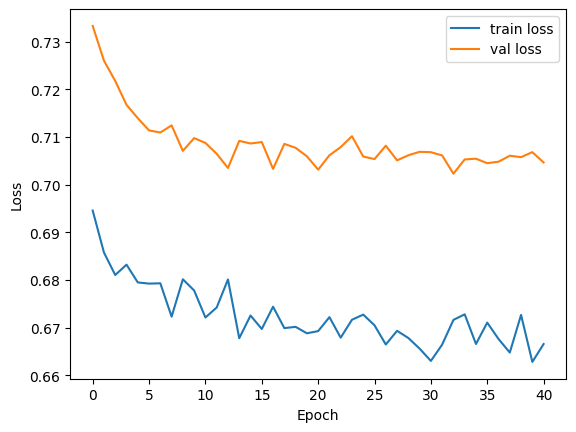

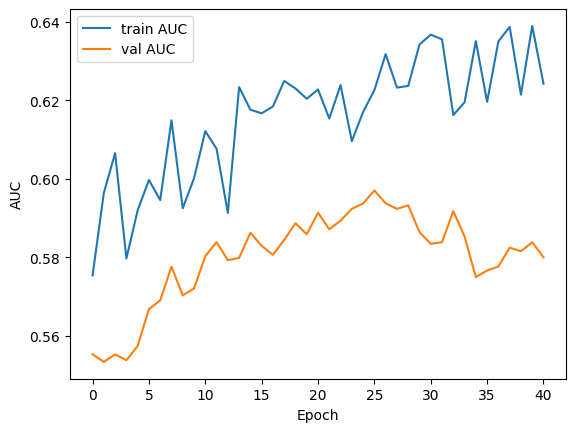

In [28]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['AUC'], label='train AUC')
plt.plot(history.history['val_AUC'], label='val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.show()

In [29]:
loss, auc, acc = model.evaluate(X_val, Y_val)
lossT, aucT, accT = model.evaluate(X_train, Y_train)

print("Train Loss: ", lossT)
print("Train Auc: ", aucT)
print("Train Accuracy: ", accT)

print("Validation Loss: ", loss)
print("Validation Auc: ", auc)
print("Validation ACcuracy: ", acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.5970 - accuracy: 0.5964 - loss: 0.7054 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.6388 - accuracy: 0.6276 - loss: 0.6654
Train Loss:  0.6654080748558044
Train Auc:  0.6388432383537292
Train Accuracy:  0.6276276111602783
Validation Loss:  0.7053744196891785
Validation Auc:  0.5970396995544434
Validation ACcuracy:  0.5963718891143799


In [30]:
from sklearn.metrics import accuracy_score

# Get probabilities from your model
y_pred_prob = model.predict(X_val).ravel()

# Try multiple thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
for t in thresholds:
    y_pred = (y_pred_prob >= t).astype(int)
    acc = accuracy_score(Y_val, y_pred)
    print(f"Threshold {t:.2f} → Accuracy {acc:.3f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Threshold 0.10 → Accuracy 0.331
Threshold 0.15 → Accuracy 0.331
Threshold 0.20 → Accuracy 0.331
Threshold 0.25 → Accuracy 0.331
Threshold 0.30 → Accuracy 0.331
Threshold 0.35 → Accuracy 0.336
Threshold 0.40 → Accuracy 0.345
Threshold 0.45 → Accuracy 0.385
Threshold 0.50 → Accuracy 0.596
Threshold 0.55 → Accuracy 0.635
Threshold 0.60 → Accuracy 0.628
Threshold 0.65 → Accuracy 0.649
Threshold 0.70 → Accuracy 0.658
Threshold 0.75 → Accuracy 0.662
Threshold 0.80 → Accuracy 0.673
Threshold 0.85 → Accuracy 0.673


## Logistic Regression Method

<p>Logistic regression is a simple yet powerful model for binary classification. It estimates the probability of an outcome based on input features, performs well on small datasets, and is easy to interpret, making it a reliable baseline for predicting customer purchases.</p>

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score

# Initialize model
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)

# Train
log_model.fit(X_train, Y_train)

# Get predicted probabilities
log_val_probs = log_model.predict_proba(X_val)[:, 1]
y_pred_log = log_model.predict(X_val)

# Compute AUC
log_auc = roc_auc_score(Y_val, log_val_probs)
log_accuracy = accuracy_score(Y_val, y_pred_log)
logm_loss = log_loss(Y_val, log_val_probs)

print("Logistic Regression Validation AUC:", log_auc)
print("Log Loss:", logm_loss)
print("Accuracy:", log_accuracy)

Logistic Regression Validation AUC: 0.5811121430229857
Log Loss: 0.6895757935771736
Accuracy: 0.6009070294784581


In [32]:
# Extract coefficients
coefs = log_model.coef_[0]

# Create a DataFrame for easy viewing
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': coefs,
    'Abs_Coefficient': abs(coefs)
})

# Sort by absolute value to see most influential features
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

feature_importance

,Feature,Coefficient,Abs_Coefficient
6,Activity_Rate_3M,-0.431500,0.431500
9,Num_SalesOrders_L3M,0.233017,0.233017
4,months_since_last_sale,-0.166201,0.166201
1,Sales_Orders_Lag_1,0.160282,0.160282
5,Activity_Ratio,0.129568,0.129568
2,Sales_Orders_Lag_2,0.120258,0.120258
0,Discount,0.113326,0.113326
3,Sales_Orders_Lag_3,0.112504,0.112504
7,Activity_Recency_Interaction,-0.049981,0.049981
8,Season_Activity_Interaction,-0.043372,0.043372


## Random Forest Model

<p><strong>Random Forest</strong> is an ensemble of decision trees that improves prediction accuracy by averaging multiple trees. It handles non-linear relationships well, is robust to noisy data, and can automatically capture feature interactions, making it suitable for intermittent sales prediction.</p>

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

# Train
rf_model.fit(X_train, Y_train)

# Predict probabilities
rf_val_probs = rf_model.predict_proba(X_val)[:, 1]

# Class predictions (threshold 0.5)
rf_val_preds = (rf_val_probs >= 0.5).astype(int)

rf_auc = roc_auc_score(Y_val, rf_val_probs)
rf_acc = accuracy_score(Y_val, rf_val_preds)
rf_loss = log_loss(Y_val, rf_val_probs)

print("Random Forest Results")
print("AUC:", rf_auc)
print("Accuracy:", rf_acc)
print("Log Loss:", rf_loss)

Random Forest Results
AUC: 0.5312050150917111
Accuracy: 0.546485260770975
Log Loss: 0.687066921599494


## XBoost Model

<p><strong>XGBoost</strong> is a gradient boosting algorithm that builds trees sequentially to correct previous errors. It is highly effective for imbalanced and sparse datasets, offers regularization to prevent overfitting, and often achieves strong predictive performance with structured tabular data.</p>

In [34]:
from xgboost import XGBClassifier

ratio = (Y_train == 0).sum() / (Y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=500,
    scale_pos_weight=ratio,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="auc",
    early_stopping_rounds=30,
    use_label_encoder=False
)

xgb_model.fit(
    X_train,
    Y_train,
    eval_set=[(X_val, Y_val)],
    verbose=False
)

# Predict probabilities
xgb_val_probs = xgb_model.predict_proba(X_val)[:, 1]

# Class predictions (threshold 0.5)
xgb_val_preds = (xgb_val_probs >= 0.5).astype(int)

xgb_auc = roc_auc_score(Y_val, xgb_val_probs)
xgb_acc = accuracy_score(Y_val, xgb_val_preds)
xgb_loss = log_loss(Y_val, xgb_val_probs)

print("XGBoost Results")
print("AUC:", xgb_auc)
print("Accuracy:", xgb_acc)
print("Log Loss:", xgb_loss)

XGBoost Results
AUC: 0.5663803111214303
Accuracy: 0.5555555555555556
Log Loss: 0.6902067627494878


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:41:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


### XGBoost — Probability Distribution Check

Before comparing models, it is worth inspecting the raw probability distribution generated by each model.
A well-functioning classifier should spread probabilities across the full 0–1 range, assigning low scores
to unlikely buyers and high scores to likely ones.
When probabilities are compressed into a narrow band,
the model is failing to discriminate between classes and effectively saying "I don't know" for every customer.

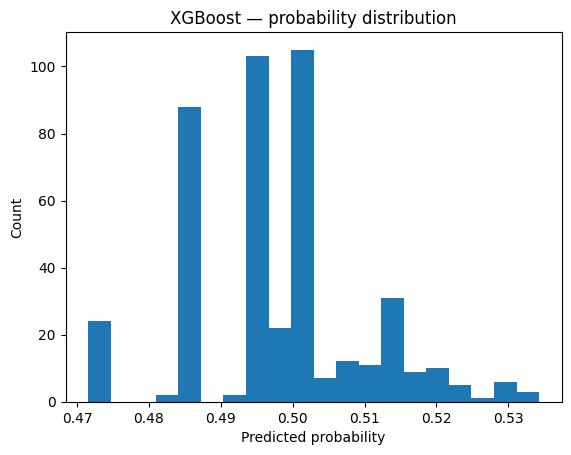

Min: 0.472
Max: 0.534
Mean: 0.498
% above 0.43: 100.0%


In [35]:
import matplotlib.pyplot as plt

plt.hist(xgb_val_probs, bins=20)
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('XGBoost — probability distribution')
plt.show()

print(f"Min: {xgb_val_probs.min():.3f}")
print(f"Max: {xgb_val_probs.max():.3f}")
print(f"Mean: {xgb_val_probs.mean():.3f}")
print(f"% above 0.43: {(xgb_val_probs >= 0.43).mean():.1%}")

The distribution confirms that **XGBoost is not discriminating between buyers and non-buyers** on this dataset.
All predicted probabilities fall between 0.47 and 0.53 which is a range so narrow that **any threshold will either
flag almost everyone or almost no one**, producing results no better than random.

This is a known limitation of gradient boosting on small, imbalanced datasets. The combination of
`scale_pos_weight`, `early_stopping`, and limited training samples caused the model to **converge
to a near-constant output** rather than learning meaningful decision boundaries.

XGBoost is kept in the comparison as a **methodological benchmark**. Its underperformance here is
itself informative as it illustrates that **model complexity is not a substitute for data volume**.

# Comparing All Models

## Model Evaluation Strategy

Accuracy is misleading on imbalanced datasets because a model that always predicts *no purchase* scores 67% without learning anything. We use **Precision** and **Recall** instead.

| Metric | Business Question
|---|---|
| **Recall (Purchase)** | Of all real buyers, how many did we catch?
| **Precision (Purchase)** | Of all contacts made, how many actually bought?

Since the cost of contacting the wrong customer is low, **Recall is the primary metric**. Precision acts as an efficiency guardrail to avoid flooding the sales team with irrelevant contacts.

**The threshold is a business decision, not a model parameter.** Lowering it captures more buyers but increases wasted contacts. Raising it does the opposite.

,Model,ROC-AUC,Precision (Purchase),Recall (Purchase),Customers to Contact %
0,Deep Learning,0.596,0.419,0.568,44.9%
1,Logistic Regression,0.581,0.411,0.473,38.1%
2,XGBoost,0.566,0.375,0.514,45.4%
3,Random Forest,0.531,0.335,0.377,37.2%


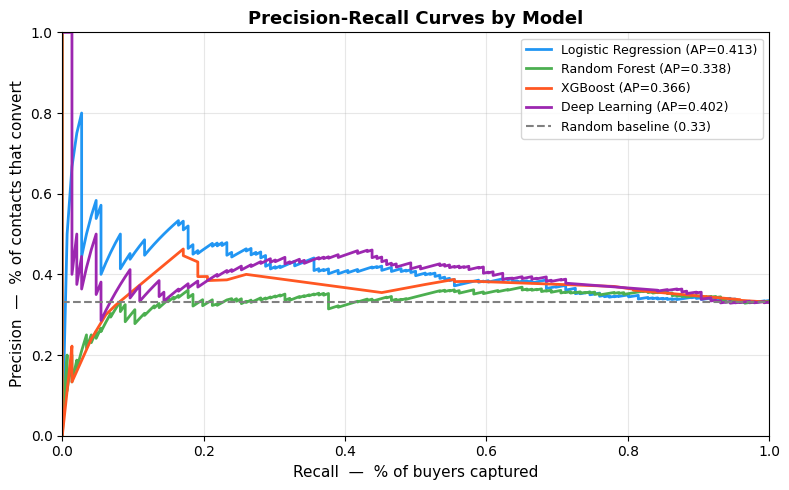

In [36]:
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import matplotlib.pyplot as plt
import pandas as pd

THRESHOLD = 0.5

# Model probabilities
models_dict = {
    'Logistic Regression' : log_val_probs,
    'Random Forest'       : rf_val_probs,
    'XGBoost'             : xgb_val_probs,
    'Deep Learning'       : y_pred_prob,
}

# Build comparison table
rows = []
for name, probs in models_dict.items():
    preds = (probs >= THRESHOLD).astype(int)
    rows.append({
        'Model'                  : name,
        'ROC-AUC'                : round(roc_auc_score(Y_val, probs), 3),
        'Precision (Purchase)'   : round(precision_score(Y_val, preds, zero_division=0), 3),
        'Recall (Purchase)'      : round(recall_score(Y_val, preds, zero_division=0), 3),
        'Customers to Contact %' : round(preds.sum() / len(preds) * 100, 1),
    })

results = (
    pd.DataFrame(rows)
    .sort_values('ROC-AUC', ascending=False)
    .reset_index(drop=True)
)

# Highlight best value per metric
styled = (
    results.style
    .highlight_max(subset=['ROC-AUC', 'Precision (Purchase)', 'Recall (Purchase)'],
                   color='#c8e6c9')
    .highlight_min(subset=['Customers to Contact %'],
                   color='#c8e6c9')
    .set_caption(f"Model comparison at threshold {THRESHOLD} — {len(Y_val)} customers in validation set")
    .format({'ROC-AUC'                : '{:.3f}',
             'Precision (Purchase)'   : '{:.3f}',
             'Recall (Purchase)'      : '{:.3f}',
             'Customers to Contact %' : '{:.1f}%'})
)
display(styled)

# Precision-Recall curves
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']
for (name, probs), color in zip(models_dict.items(), colors):
    precision, recall, _ = precision_recall_curve(Y_val, probs)
    ap = average_precision_score(Y_val, probs)
    ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})",
            color=color, linewidth=2)

ax.axhline(y=Y_val.mean(), color='gray', linestyle='--',
           linewidth=1.5, label=f'Random baseline ({Y_val.mean():.2f})')

ax.set_xlabel('Recall  —  % of buyers captured', fontsize=11)
ax.set_ylabel('Precision  —  % of contacts that convert', fontsize=11)
ax.set_title('Precision-Recall Curves by Model', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Results Interpretation

## Conclusion
**Deep Learning at threshold 0.50** is the recommended production model. It achieves the highest ROC-AUC (0.590) and captures the most next-month buyers, delivering a ranked and filtered contact list to the sales team. Logistic Regression and Random Forest are included as methodological benchmarks and would be re-evaluated with a larger dataset.

# Model vs Random Outreach

A model is only useful if it outperforms the simplest possible alternative.
Here we compare the selected model against a random outreach strategy
using the **same number of contacts** and isolating the model's contribution
from the effect of contact volume alone.

The random baseline is simulated 1,000 times to produce a stable average,
removing the effect of lucky or unlucky draws.

In [37]:
import numpy as np
import pandas as pd

# Model performance at chosen threshold
best_probs = y_pred_prob
best_preds = (best_probs >= THRESHOLD).astype(int)

model_contacts        = int(best_preds.sum())
model_precision       = precision_score(Y_val, best_preds, zero_division=0)
model_recall          = recall_score(Y_val, best_preds, zero_division=0)
model_buyers_captured = int((best_preds & Y_val.astype(int)).sum())
total_buyers          = int(Y_val.sum())

# Random baseline (same number of contacts, 1000 simulations)
np.random.seed(42)
n_simulations = 1000
random_precisions = []
random_recalls    = []
random_buyers     = []

for _ in range(n_simulations):
    random_preds = np.zeros(len(Y_val), dtype=int)
    random_idx   = np.random.choice(len(Y_val), size=model_contacts, replace=False)
    random_preds[random_idx] = 1

    random_precisions.append(precision_score(Y_val, random_preds, zero_division=0))
    random_recalls.append(recall_score(Y_val, random_preds, zero_division=0))
    random_buyers.append(int((random_preds & Y_val.astype(int)).sum()))

avg_random_precision = np.mean(random_precisions)
avg_random_recall    = np.mean(random_recalls)
avg_random_buyers    = np.mean(random_buyers)

# Lift calculation
precision_lift = ((model_precision / avg_random_precision) - 1) * 100
recall_lift    = ((model_recall    / avg_random_recall)    - 1) * 100
buyers_lift    = ((model_buyers_captured / avg_random_buyers) - 1) * 100

# Comparison table
comparison = pd.DataFrame([
    {
        'Approach'         : 'Random outreach',
        'Contacts made'    : f'{model_contacts} ({model_contacts/len(Y_val):.1%})',
        'Buyers captured'  : f'{avg_random_buyers:.1f} / {total_buyers}',
        'Precision'        : f'{avg_random_precision:.3f}',
        'Recall'           : f'{avg_random_recall:.3f}',
        'Lift vs random'   : '—',
    },
    {
        'Approach'         : 'Deep Learning',
        'Contacts made'    : f'{model_contacts} ({model_contacts/len(Y_val):.1%})',
        'Buyers captured'  : f'{model_buyers_captured} / {total_buyers}',
        'Precision'        : f'{model_precision:.3f}',
        'Recall'           : f'{model_recall:.3f}',
        'Lift vs random'   : f'+{precision_lift:.1f}% precision  |  +{buyers_lift:.1f}% buyers captured',
    },
])

styled = (
    comparison.style
    .apply(lambda x: ['background: #e8f2f8; font-weight: 500'
                       if x['Approach'] == 'Deep Learning'
                       else '' for _ in x], axis=1)
    .set_caption(f"Deep Learning vs random outreach — {model_contacts} contacts, {n_simulations} simulations")
    .hide(axis='index')
)
display(styled)

Approach,Contacts made,Buyers captured,Precision,Recall,Lift vs random
Random outreach,198 (44.9%),65.5 / 146,0.331,0.449,—
Deep Learning,198 (44.9%),83 / 146,0.419,0.568,+26.6% precision | +26.6% buyers captured


# Model Export

Based on the evaluation results, **Deep Learning** was selected as the production model at threshold 0.50,
capturing more potential buyers than any other model evaluated.

Note: due to the stochastic nature of neural network training, results may vary slightly
between runs. Re-exporting after retraining is recommended if the notebook is re-executed.

The trained model and scaler are saved to Google Drive for use in the scoring notebook.

In [38]:
import joblib
import json
import os
from google.colab import drive
from tensorflow import keras

# Mount Google Drive
drive.mount('/content/drive')

# Save path
SAVE_PATH = '/content/drive/MyDrive/Intermitent_sales_model_ML/'
os.makedirs(SAVE_PATH, exist_ok=True)

# Save Deep Learning model (Keras native format)
model.save(SAVE_PATH + 'best_model.keras')

# Save scaler
joblib.dump(scaler, SAVE_PATH + 'scaler.pkl')

# Save metadata for use in scoring notebook
metadata = {
    'model_name'   : 'Deep Learning',
    'threshold'    : THRESHOLD,
    'feature_cols' : feature_cols
}
with open(SAVE_PATH + 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Files saved to {SAVE_PATH}")
print(f"  best_model.keras     — Deep Learning (Keras)")
print(f"  scaler.pkl           — StandardScaler fitted on training data")
print(f"  model_metadata.json  — threshold: {THRESHOLD}, features: {len(feature_cols)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files saved to /content/drive/MyDrive/Intermitent_sales_model_ML/
  best_model.keras     — Deep Learning (Keras)
  scaler.pkl           — StandardScaler fitted on training data
  model_metadata.json  — threshold: 0.5, features: 10
